<a href="https://colab.research.google.com/github/humairasundas220/DevelopersHub_ML_Internship/blob/main/Task3_Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3: Heart Disease Prediction

## Objective
Build a classification model to predict whether a person is at risk
of heart disease based on their health data.

## Dataset
Heart Disease UCI Dataset (sourced from Kaggle)

In [1]:
# Get the Heqart Disease UCI dataset from kaggle
import pandas as pd

url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.head())

(303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


### Dataset
- Loaded the Heart Disease UCI dataset directly from a CSV source.
- Dataset contains patient health records used to predict heart disease risk.
- Each row represents one patient; columns include health indicators like
  age, cholesterol, blood pressure, and a target column indicating
  presence of heart disease.
  ### Dataset Structure
- 303 patient records, 14 columns total.
- Features include: age, sex, chest pain type (cp), resting blood
  pressure (trestbps), cholesterol (chol), fasting blood sugar (fbs),
  resting ECG (restecg), max heart rate (thalach), exercise-induced
  angina (exang), and others.
- Target column: `target` (1 = heart disease present, 0 = no heart disease).

In [2]:
# Data Cleaning
# Checking for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Checking for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Checking data types
print("\nData types:")
print(df.dtypes)

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows: 1

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [3]:
# Removimng duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (302, 14)


### Data Cleaning Results
- No missing values found in any column.
- Found and removed 1 duplicate row.
- Final dataset shape: 302 rows, 14 columns — clean and ready for analysis.

target
1    164
0    138
Name: count, dtype: int64


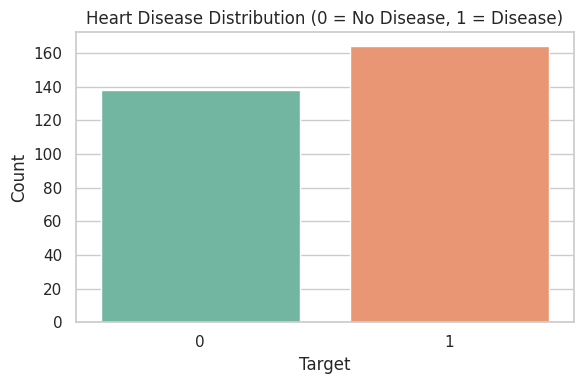

In [5]:
# Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
# Target Distribution
print(df['target'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', hue='target', palette='Set2', legend=False)
plt.title('Heart Disease Distribution (0 = No Disease, 1 = Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### EDA: Target Distribution Results
- 164 patients have heart disease (54%), 138 do not (46%).
- Classes are reasonably balanced — no major class imbalance,
  so accuracy will be a meaningful evaluation metric.

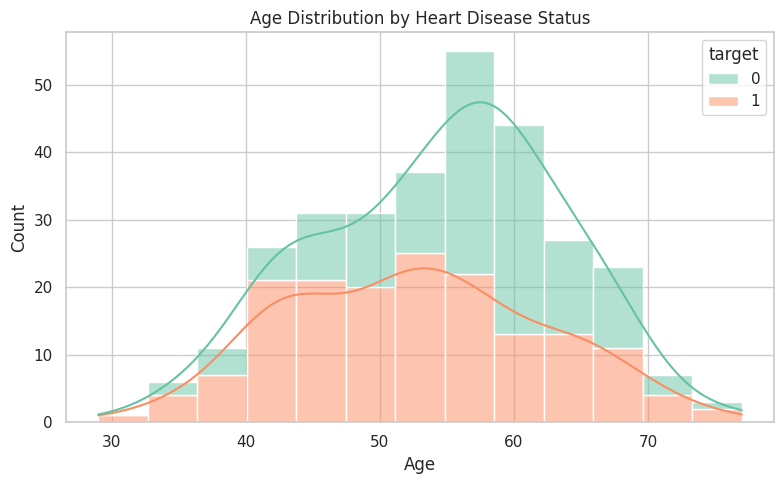

In [6]:
# Age distribution (EDA)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='target', kde=True, palette='Set2', multiple='stack')
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### EDA: Age Distribution Results
- Most patients fall in the 45-65 age range, regardless of heart disease status.
- Heart disease cases (target=1) peak around age 50-55.
- Age alone doesn't sharply separate the two groups — overlap is significant,
  suggesting age is a contributing factor but not a standalone predictor.

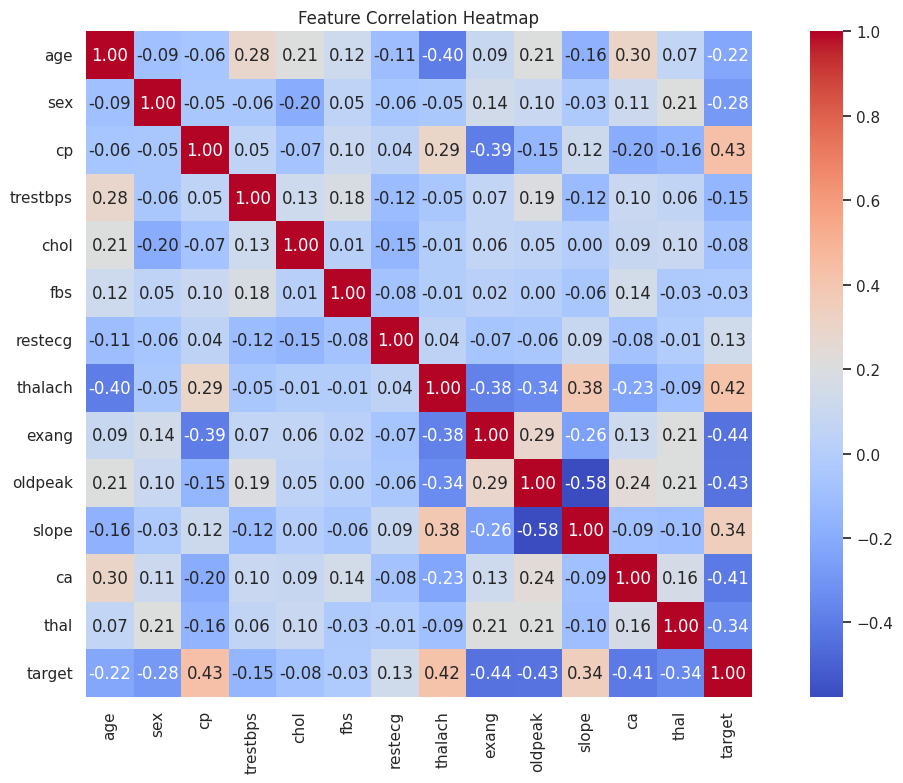

In [7]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### EDA: Correlation Analysis Results
- Strongest predictors of heart disease (by correlation with target):
  - `cp` (chest pain type): +0.43
  - `thalach` (max heart rate achieved): +0.42
  - `exang` (exercise-induced angina): -0.44
  - `oldpeak` (ST depression): -0.43
  - `ca` (number of major vessels): -0.41
- These 5 features show the strongest relationship with heart disease
  risk and are likely to be important for the classification model.
- No single feature is overwhelmingly dominant — disease risk depends
  on a combination of factors, which justifies using a machine learning
  model rather than a simple threshold rule.

In [9]:
# Prepare data for modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Train-test split (80/20, stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (241, 13)
Test shape: (61, 13)


### Preprocessing Notes
- Separated features (X) and target variable (y).
- Split data into 80% training (241 samples) and 20% testing (61 samples),
  using stratified sampling to preserve the same heart disease ratio
  in both sets.
- Applied StandardScaler to normalize features — fit on training data
  only, then applied to test data, to avoid data leakage.
- Logistic Regression requires scaled features since it's sensitive
  to differences in feature magnitude (e.g., age vs. cholesterol).

In [10]:
# Train the classification model (Logistic Regression model)
from sklearn.linear_model import LogisticRegression

# Train
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = model.predict(X_test_scaled)

print("Model trained successfully!")

Model trained successfully!


### Model Training Notes
- Trained a Logistic Regression model for binary classification
  (heart disease: yes/no).
- Logistic Regression was chosen for its interpretability —
  coefficients directly show each feature's influence on risk.

In [11]:
# Evaluate the model using metric (Accuracy, Confusion matrix and ROC curve)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.79

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.68      0.75        28
           1       0.76      0.88      0.82        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.78        61


Confusion Matrix:
[[19  9]
 [ 4 29]]


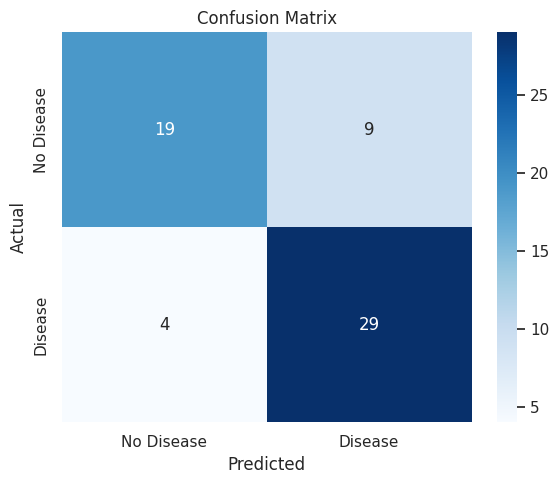

In [12]:
# Visualizing Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

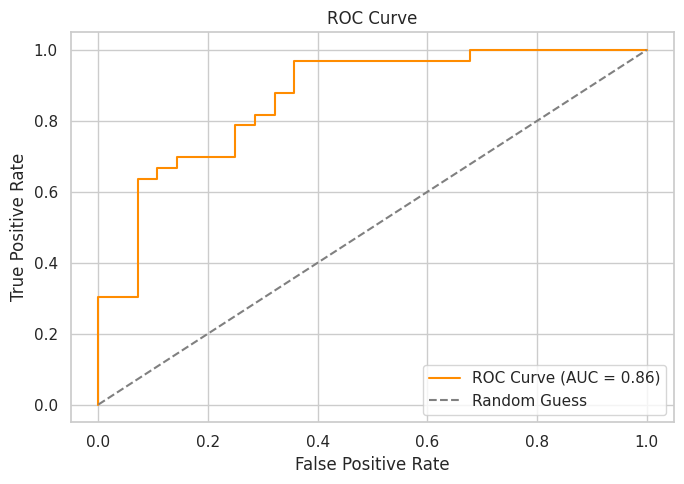

In [13]:
# Visualizing ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

### Evaluation Results
- **Accuracy: 79%** — the model correctly classifies patients 79% of the time.
- **Confusion Matrix:**
  - True Negatives: 19, False Positives: 9
  - False Negatives: 4, True Positives: 29
- **Recall for Disease class: 88%** — the model correctly identifies
  88% of actual heart disease cases, important since missing a true
  case is more costly in a medical context than a false alarm.
- **AUC Score: 0.86** — indicates strong ability to distinguish between
  disease and no-disease cases across all thresholds (closer to 1.0 is better).
- Overall, the model performs well and is reasonably reliable for
  this type of medical screening task.

     Feature  Coefficient
2         cp     0.952331
1        sex    -0.736645
9    oldpeak    -0.666385
7    thalach     0.579053
12      thal    -0.576275
11        ca    -0.556723
8      exang    -0.464419
4       chol    -0.454237
6    restecg     0.263408
3   trestbps    -0.258203
10     slope     0.230875
5        fbs    -0.054464
0        age     0.030360


/tmp/ipykernel_4550/4054151407.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Coefficient', y='Feature', palette='coolwarm')


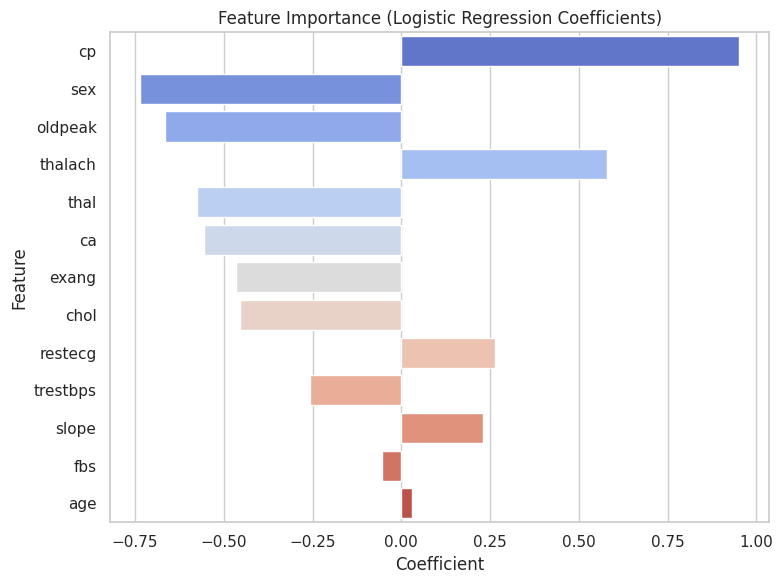

In [14]:
# Feature Importance
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(importance)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.tight_layout()
plt.show()

### Feature Importance Results
- **Most influential features:**
  - `cp` (chest pain type): +0.95 — strongest predictor, higher severity increases risk
  - `sex`: -0.74 — significant influence based on gender
  - `oldpeak` (ST depression): -0.67
  - `thalach` (max heart rate achieved): +0.58
  - `thal` and `ca`: also strong negative influences
- `age` and `fbs` (fasting blood sugar) had minimal influence on predictions,
  contrary to common assumption that age is a dominant risk factor.
- These results align with medical knowledge — chest pain type and
  cardiovascular stress test results (thalach, oldpeak) are well-known
  clinical indicators of heart disease.

### Final Conclusion
- Built a Logistic Regression model to predict heart disease risk using
  13 health features from the UCI Heart Disease dataset.
- Achieved **79% accuracy** and a strong **AUC of 0.86**, showing reliable
  classification performance.
- The model has high recall (88%) for detecting actual disease cases,
  which is valuable in a medical screening context where missing a
  true case is costly.
- Chest pain type, sex, max heart rate, and ST depression were the
  most influential predictors.
- Future improvement: try a Decision Tree or Random Forest model to
  compare performance and capture potential non-linear relationships.